# Matplotlib - FAQ (Często Zadawane Pytania)

Ten notatnik zawiera **rozszerzone wyjaśnienia** kwestii, które mogą być niejasne w głównych materiałach.

---

## 📋 Spis treści

1. [Pyplot vs OO-style - jaka jest różnica?](#1-pyplot-vs-oo-style---jaka-jest-różnica)
2. [Jakie są typy Artists i do czego służą?](#2-jakie-są-typy-artists-i-do-czego-służą)
3. [Co oznacza figsize i DPI? Jak wykres wyświetla się na ekranie?](#3-co-oznacza-figsize-i-dpi-jak-wykres-wyświetla-się-na-ekranie)
4. [Czym jest backend i dlaczego matplotlib nie wyświetla wykresów w skrypcie?](#4-czym-jest-backend-i-dlaczego-matplotlib-nie-wyświetla-wykresów-w-skrypcie)
5. *(Miejsce na kolejne pytania)*

---

## 1. Pyplot vs OO-style - jaka jest różnica?

### 🎯 Krótka odpowiedź

**Pyplot (MATLAB-style):** Globalny stan z niejawnymi operacjami - funkcje działają na "aktualnym wykresie"

**OO-style:** Jawne obiekty z pełną kontrolą - zawsze wiadomo na którym wykresie pracujesz

---

### 📚 Szczegółowe wyjaśnienie

#### **Pyplot interface = STATEFUL (stanowy)**

Pyplot to **interfejs stanowy** (stateful) - oznacza to, że matplotlib wewnętrznie śledzi "aktualny wykres" i wszystkie operacje wykonywane są na tym niejawnym obiekcie.

**Analogia:** To jak malowanie na płótnie które **jest teraz na sztaludze**. Nie mówisz "na którym płótnie malam", bo jest tylko jedno "aktualne". Jeśli chcesz malować na innym, musisz je **zamienić na sztaludze**.

**Charakterystyka:**
- 🌐 **Globalny stan** - pyplot automatycznie śledzi "aktualny wykres" (current figure/axes)
- 🎯 **Funkcje globalne** - `plt.plot()`, `plt.title()`, `plt.xlabel()` działają na tym aktualnym wykresie
- ⚡ **Szybki start** - dobry do szybkiej eksploracji danych i prostych wykresów
- ⚠️ **Niejawność** - możesz nie wiedzieć na którym wykresie pracujesz
- 🔀 **Przełączanie kontekstu** - musisz używać `plt.figure(n)` żeby przełączyć się między wykresami

#### **OO-style = STATELESS (bezstanowy)**

Object-oriented interface to **interfejs bezstanowy** (stateless) - sam tworzysz i przechowujesz referencje do wykresów (Figure, Axes), a potem wywoływujesz metody na tych konkretnych obiektach.

**Analogia:** To jak malowanie z **paletą wielu płócien przed sobą**. Wybierasz konkretne płótno do każdego pociągnięcia pędzla. Nie ma "aktualnego" płótna - wszystko jest jawne.

**Charakterystyka:**
- 🎨 **Jawne obiekty** - sam tworzysz Figure i Axes, masz do nich bezpośrednie referencje
- 🔧 **Metody obiektów** - `ax.plot()`, `ax.set_title()`, `ax.set_xlabel()` działają na konkretnym obiekcie
- 💎 **Klarowny kod** - zawsze wiadomo z którym wykresem pracujesz (nie ma "magii")
- ✅ **Profesjonalny** - lepszy dla skryptów produkcyjnych, funkcji, złożonych wykresów
- 🧩 **Kompozycja** - łatwe tworzenie dashboardów z wieloma wykresami

---

### 💻 Przykłady kodu - porównanie

In [2]:
import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline

#### Przykład 1: Prosty wykres - oba style

1️⃣ PYPLOT STYLE (globalny stan)


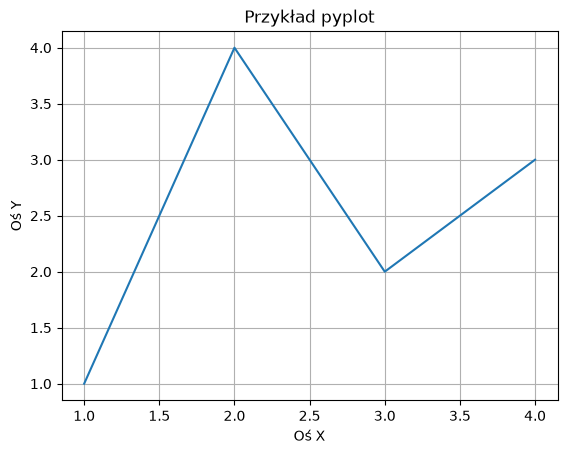

✅ Proste i szybkie, ale... na którym wykresie to było?
   (matplotlib śledzi to wewnętrznie)


In [2]:
# ===== PYPLOT STYLE =====
print("1️⃣ PYPLOT STYLE (globalny stan)")

# Wszystko przez funkcje globalne plt.*
plt.plot([1, 2, 3, 4], [1, 4, 2, 3])  # Automatycznie tworzy figure + axes
plt.title("Przykład pyplot")
plt.xlabel("Oś X")
plt.ylabel("Oś Y")
plt.grid(True)
plt.show()

print("✅ Proste i szybkie, ale... na którym wykresie to było?")
print("   (matplotlib śledzi to wewnętrznie)")

2️⃣ OO STYLE (jawne obiekty)


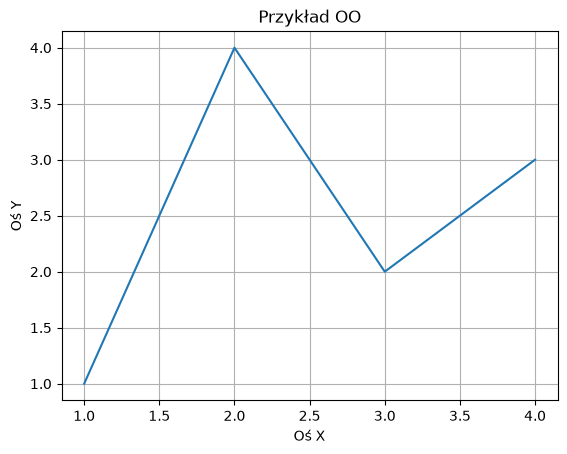

✅ Jasne i precyzyjne - wszystko na obiekcie 'ax'
   fig = <class 'matplotlib.figure.Figure'>, ax = <class 'matplotlib.axes._axes.Axes'>


In [3]:
# ===== OO STYLE =====
print("2️⃣ OO STYLE (jawne obiekty)")

# Jawnie tworzę Figure i Axes
fig, ax = plt.subplots()

# Wszystko przez metody obiektu ax.*
ax.plot([1, 2, 3, 4], [1, 4, 2, 3])
ax.set_title("Przykład OO")
ax.set_xlabel("Oś X")
ax.set_ylabel("Oś Y")
ax.grid(True)
plt.show()

print("✅ Jasne i precyzyjne - wszystko na obiekcie 'ax'")
print(f"   fig = {type(fig)}, ax = {type(ax)}")

#### Przykład 2: Problem z pyplot - wiele wykresów

⚠️ PYPLOT - Problem z wieloma wykresami

Narysuję czerwoną linię na figurze 1...
Teraz jestem na figurze 2, rysuję niebieską linię...
Wróciłem do figury 1, dodaję zieloną linię...


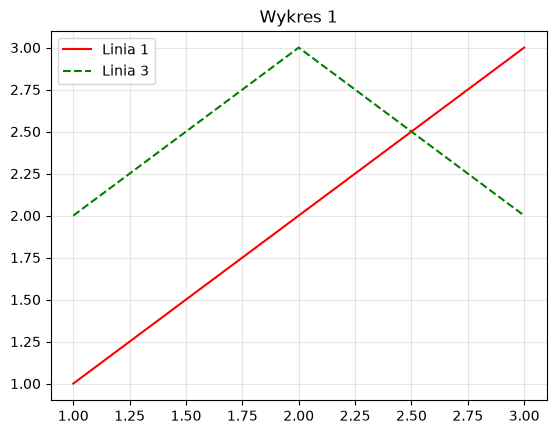

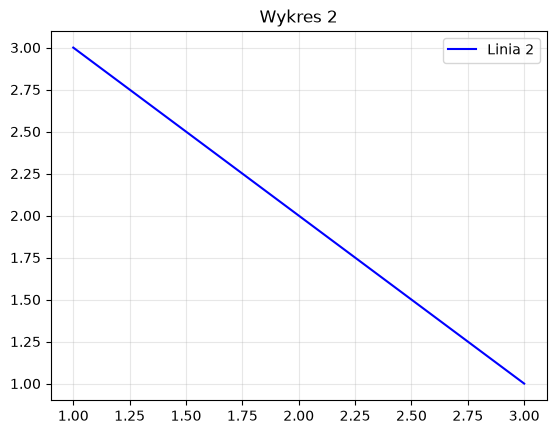


⚠️ PROBLEM: Muszę pamiętać na której figurze jestem!
   Co jeśli zapomniałbym plt.figure(1) przed dodaniem zielonej linii?
   Trafiłaby na wykres 2! Bug!


In [4]:
# ===== PYPLOT - MYLĄCE! =====
print("⚠️ PYPLOT - Problem z wieloma wykresami")
print()

# Wyczyść wszystkie poprzednie figury aby uniknąć konfliktów
plt.close('all')

# Rysuję na figurze 1
plt.figure(1)
plt.plot([1, 2, 3], [1, 2, 3], 'r-', label='Linia 1')
plt.title("Wykres 1")
print("Narysuję czerwoną linię na figurze 1...")

# Przełączam się na figurę 2
plt.figure(2)
plt.plot([1, 2, 3], [3, 2, 1], 'b-', label='Linia 2')
plt.title("Wykres 2")
print("Teraz jestem na figurze 2, rysuję niebieską linię...")

# ⚠️ UWAGA! Teraz chcę dodać coś do wykresu 1
# Muszę PAMIĘTAĆ żeby wrócić do figury 1!
plt.figure(1)  # ⚠️ Łatwo zapomnieć!
plt.plot([1, 2, 3], [2, 3, 2], 'g--', label='Linia 3')
print("Wróciłem do figury 1, dodaję zieloną linię...")

# Wyświetl oba wykresy
plt.figure(1)
plt.legend()
plt.grid(True, alpha=0.3)

plt.figure(2)
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()  # Pokazuje wszystkie otwarte figury

print("\n⚠️ PROBLEM: Muszę pamiętać na której figurze jestem!")
print("   Co jeśli zapomniałbym plt.figure(1) przed dodaniem zielonej linii?")
print("   Trafiłaby na wykres 2! Bug!")

✅ OO STYLE - Brak problemów z wieloma wykresami

Rysuję czerwoną linię na ax1...
Rysuję niebieską linię na ax2...
Dodaję zieloną linię do ax1 - wszystko jasne!


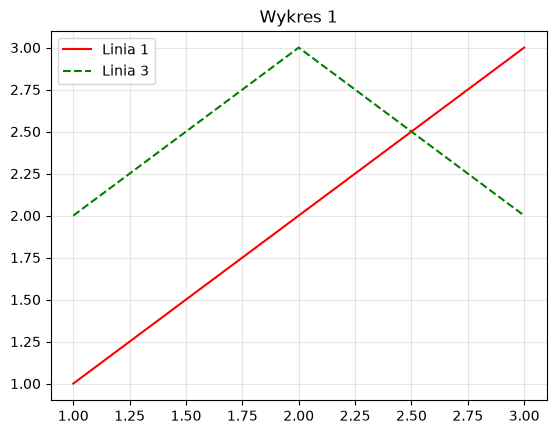

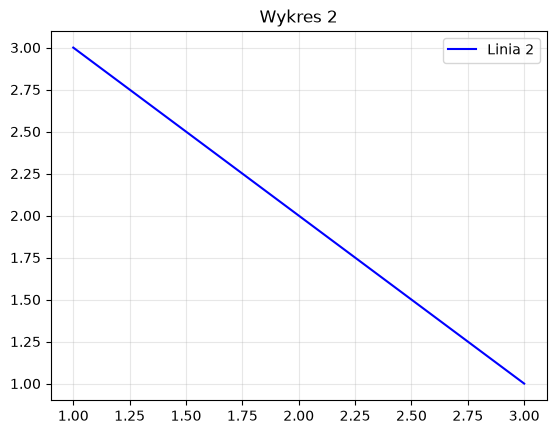


✅ BRAK PROBLEMÓW: Wszystko jawne!
   ax1 to ax1, ax2 to ax2. Nie mogę się pomylić!


In [5]:
# ===== OO STYLE - KLAROWNE! =====
print("✅ OO STYLE - Brak problemów z wieloma wykresami")
print()

# Jawnie tworzę dwa wykresy
fig1, ax1 = plt.subplots()
fig2, ax2 = plt.subplots()

# Rysuję na pierwszym
ax1.plot([1, 2, 3], [1, 2, 3], 'r-', label='Linia 1')
ax1.set_title("Wykres 1")
print("Rysuję czerwoną linię na ax1...")

# Rysuję na drugim
ax2.plot([1, 2, 3], [3, 2, 1], 'b-', label='Linia 2')
ax2.set_title("Wykres 2")
print("Rysuję niebieską linię na ax2...")

# Dodaję coś do pierwszego - ZERO pomyłek!
ax1.plot([1, 2, 3], [2, 3, 2], 'g--', label='Linia 3')
print("Dodaję zieloną linię do ax1 - wszystko jasne!")

ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.legend()
ax2.grid(True, alpha=0.3)

plt.show()

print("\n✅ BRAK PROBLEMÓW: Wszystko jawne!")
print("   ax1 to ax1, ax2 to ax2. Nie mogę się pomylić!")

#### Przykład 3: Dashboard (grid wykresów) - PYPLOT vs OO

**Stwórzmy dashboard z 4 wykresami (2x2). Najpierw w pyplot, potem w OO-style.**

In [ ]:
# ===== PYPLOT STYLE - Dashboard 2x2 - KOSZMARNE! =====
print("😱 PYPLOT STYLE - Dashboard z 4 wykresami (2x2)")
print()

plt.close('all')

# Tworzę figurę i ustawiam rozmiar
plt.figure(figsize=(12, 8))

# ⚠️ Wykres 1 (lewy górny) - pozycja 1
print("Przełączam się na subplot(2, 2, 1)...")
plt.subplot(2, 2, 1)  # 2 wiersze, 2 kolumny, pozycja 1
plt.plot([1, 2, 3], [1, 4, 9], 'r-')
plt.title("Wykres 1: x²")
plt.grid(True)

# ⚠️ Wykres 2 (prawy górny) - pozycja 2
print("Przełączam się na subplot(2, 2, 2)...")
plt.subplot(2, 2, 2)  # 2 wiersze, 2 kolumny, pozycja 2
plt.plot([1, 2, 3], [1, 2, 3], 'g-')
plt.title("Wykres 2: liniowy")
plt.grid(True)

# ⚠️ Wykres 3 (lewy dolny) - pozycja 3
print("Przełączam się na subplot(2, 2, 3)...")
plt.subplot(2, 2, 3)  # 2 wiersze, 2 kolumny, pozycja 3
x = np.linspace(0, 2*np.pi, 50)
plt.plot(x, np.sin(x), 'b-')
plt.title("Wykres 3: sin(x)")
plt.grid(True)

# ⚠️ Wykres 4 (prawy dolny) - pozycja 4
print("Przełączam się na subplot(2, 2, 4)...")
plt.subplot(2, 2, 4)  # 2 wiersze, 2 kolumny, pozycja 4
plt.plot(x, np.cos(x), 'm-')
plt.title("Wykres 4: cos(x)")
plt.grid(True)

plt.tight_layout()
plt.show()

print("\n😱 PROBLEMY:")
print("   1. subplot(2,2,1), subplot(2,2,2)... - musisz liczyć pozycje!")
print("   2. Co to znaczy '1', '2', '3', '4'? Nieczytelne!")
print("   3. Chcesz wrócić do wykresu 1? subplot(2,2,1) jeszcze raz!")
print("   4. Łatwo się pomylić w numeracji!")
print("   5. A co jeśli chcesz 3x3? subplot(3,3,1), (3,3,2)... (3,3,9)!")
print("\n🤯 Im więcej wykresów, tym większy CHAOS!")

🎨 OO STYLE - Dashboard z 4 wykresami (2x2)


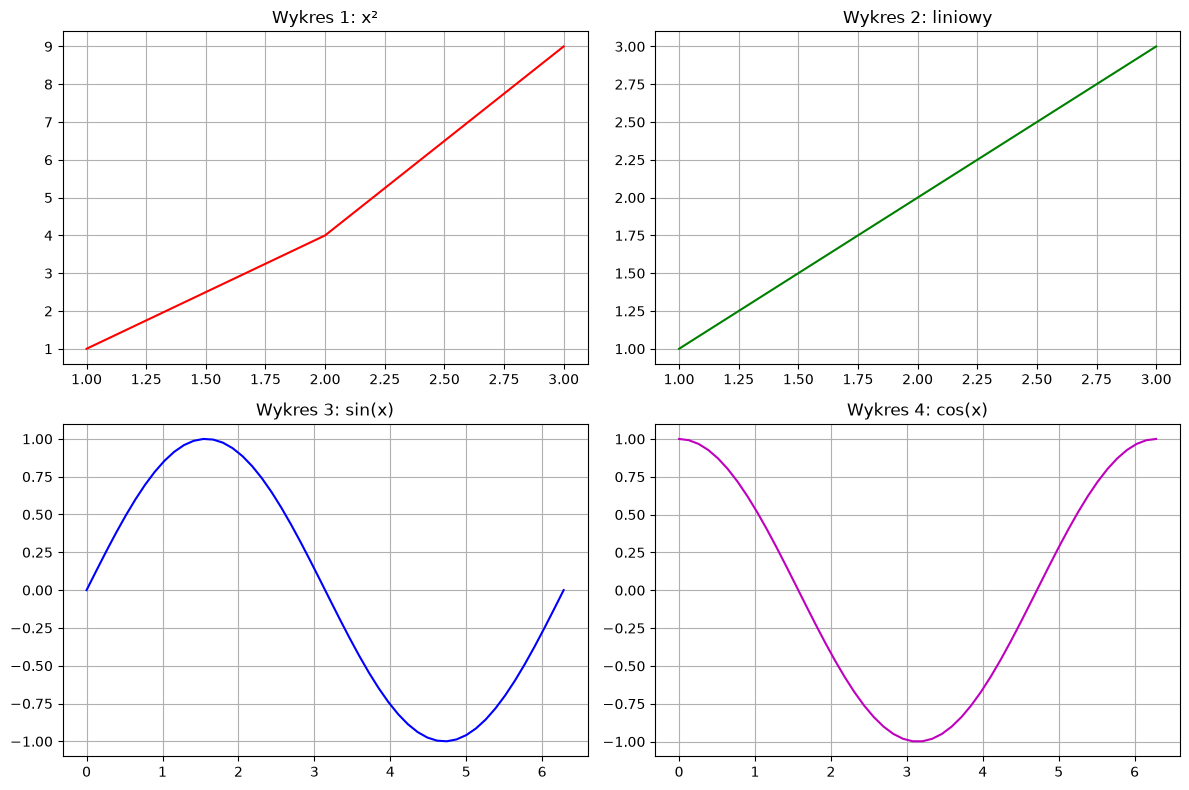


✅ KLAROWNE! axes[wiersz, kolumna] - zawsze wiesz który wykres modyfikujesz

⚠️ Spróbuj to zrobić w pyplot - będzie KOSZMAREM!
   (plt.subplot(2,2,1), plt.subplot(2,2,2)... i zgubisz się!)


In [6]:
# ===== OO STYLE - Dashboard 2x2 =====
print("🎨 OO STYLE - Dashboard z 4 wykresami (2x2)")

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# axes to tablica 2x2, więc axes[0,0] to lewy górny, axes[1,1] to prawy dolny

# Wykres 1 (lewy górny)
axes[0, 0].plot([1, 2, 3], [1, 4, 9], 'r-')
axes[0, 0].set_title("Wykres 1: x²")
axes[0, 0].grid(True)

# Wykres 2 (prawy górny)
axes[0, 1].plot([1, 2, 3], [1, 2, 3], 'g-')
axes[0, 1].set_title("Wykres 2: liniowy")
axes[0, 1].grid(True)

# Wykres 3 (lewy dolny)
x = np.linspace(0, 2*np.pi, 50)
axes[1, 0].plot(x, np.sin(x), 'b-')
axes[1, 0].set_title("Wykres 3: sin(x)")
axes[1, 0].grid(True)

# Wykres 4 (prawy dolny)
axes[1, 1].plot(x, np.cos(x), 'm-')
axes[1, 1].set_title("Wykres 4: cos(x)")
axes[1, 1].grid(True)

plt.tight_layout()
plt.show()

print("\n✅ KLAROWNE! axes[wiersz, kolumna] - zawsze wiesz który wykres modyfikujesz")
print("\n⚠️ Spróbuj to zrobić w pyplot - będzie KOSZMAREM!")
print("   (plt.subplot(2,2,1), plt.subplot(2,2,2)... i zgubisz się!)")

---

### 🎯 Kiedy używać którego stylu?

#### ✅ Używaj **PYPLOT** gdy:

- Robisz **szybką eksplorację** danych w interaktywnej sesji
- Tworzysz **jeden prosty wykres**
- Nie planujesz **modyfikować kodu** ani go używać w skrypcie
- Jesteś **przyzwyczajony do MATLAB-a**

**Przykład:** Jupyter notebook do szybkiej analizy danych

```python
# Szybka eksploracja
plt.plot(df['data'], df['temperatura'])
plt.show()
```

---

#### ✅ Używaj **OO-STYLE** gdy:

- Tworzysz **więcej niż jeden wykres**
- Piszesz **funkcje** lub **skrypty** które generują wykresy
- Chcesz **pełną kontrolę** nad każdym elementem
- Tworzysz **dashboardy** lub **złożone layouty**
- Pracujesz w **zespole** (klarowność kodu!)
- Kod ma trafić do **produkcji**

**Przykład:** Funkcja generująca raport z wieloma wykresami

```python
def create_dashboard(data):
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    axes[0, 0].plot(data['x'], data['y1'])
    axes[0, 1].plot(data['x'], data['y2'])
    # ...
    return fig
```

---

### 💡 Rekomendacja dla tego kursu

**Używaj OO-style jako domyślnego!** 

Dlaczego?
- ✅ Nauczysz się **dobrych praktyk** od razu
- ✅ Kod będzie **klarowny i łatwy do debugowania**
- ✅ Łatwo przejdziesz do **zaawansowanych technik**
- ✅ Twój kod będzie **production-ready**

**BONUS:** Jak już opanujesz OO-style, pyplot będzie dla Ciebie **trywialny** (odwrotnie nie koniecznie!).

---

### 📖 Podsumowanie różnic

| Aspekt | Pyplot (MATLAB-style) | OO-style (Object-oriented) |
|--------|----------------------|---------------------------|
| **Stan** | STATEFUL (globalny) | STATELESS (jawny) |
| **API** | Funkcje globalne `plt.*` | Metody obiektów `ax.*`, `fig.*` |
| **Klarowność** | ⚠️ Niejawny "aktualny wykres" | ✅ Wszystko jawne |
| **Łatwość startu** | ✅ Bardzo szybkie | ⚠️ Wymaga `subplots()` |
| **Wiele wykresów** | ⚠️ Mylące (trzeba przełączać) | ✅ Klarowne (każdy ma swoją referencję) |
| **Dashboardy** | ❌ Koszmarne | ✅ Naturalne |
| **Funkcje/skrypty** | ⚠️ Ryzykowne (side effects) | ✅ Bezpieczne |
| **Debugowanie** | ⚠️ Trudne (gdzie jest błąd?) | ✅ Łatwe (która linia?) |
| **Typowe użycie** | Eksploracja interaktywna | Kod produkcyjny |

---

### 🔗 Zobacz też

- [Matplotlib - Official guide on pyplot vs OO](https://matplotlib.org/stable/tutorials/introductory/usage.html#the-object-oriented-interface-and-the-pyplot-interface)
- Notebook główny: `02_matplotlib_part1.ipynb` - sekcja 1

---

## 2. Jakie są typy Artists i do czego służą?

### 🎯 Krótka odpowiedź

**Artist** = każdy element wizualny na wykresie (linie, tekst, kształty, osie, legenda...)

Wszystko co widzisz na wykresie to Artist!

---

### 📚 Szczegółowe wyjaśnienie

W matplotlib **wszystko jest Artist-em** (obiekt klasy `Artist`). Każdy element wizualny dziedziczy po tej klasie.

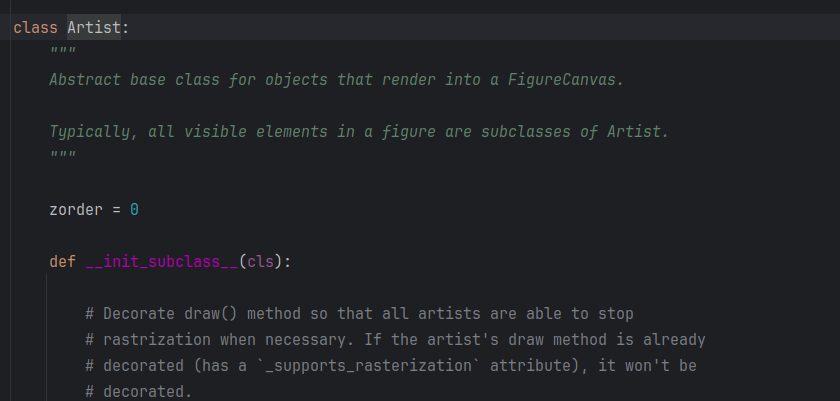

#### Hierarchia Artists:

```
Artist (bazowa klasa abstrakcyjna)
├── Figure (całe płótno)
├── Axes (wykres/subplot)
├── Axis (oś X lub Y)
└── Primitive Artists (elementy wizualne):
    ├── Line2D (linie, krzywe)
    ├── Patch (wypełnione kształty: Rectangle, Circle, Polygon...)
    ├── Text (teksty: tytuły, etykiety, adnotacje)
    ├── Collection (kolekcje: scatter points, histogramy)
    ├── Spine (krawędzie wykresu)
    ├── Legend (legenda)
    └── inne...
```

#### Najważniejsze typy:

| Typ | Co to jest | Przykład użycia |
|-----|------------|-----------------|
| **Line2D** | Linia/krzywa | `ax.plot()` zwraca Line2D |
| **Patch** | Wypełniony kształt | Rectangle (słupek), Circle (koło) |
| **Text** | Tekst | Tytuły, etykiety, adnotacje |
| **Spine** | Krawędź wykresu | 4 ramki: left, right, top, bottom |
| **Axis** | Oś (X lub Y) | Podziałki, etykiety osi |
| **Legend** | Legenda | `ax.legend()` tworzy Legend |
| **Collection** | Zbiór obiektów | Scatter plot, histogram bars |

---

### 💻 Przykłady kodu - izolacja każdego typu Artist

📈 LINE2D - Linia/krzywa



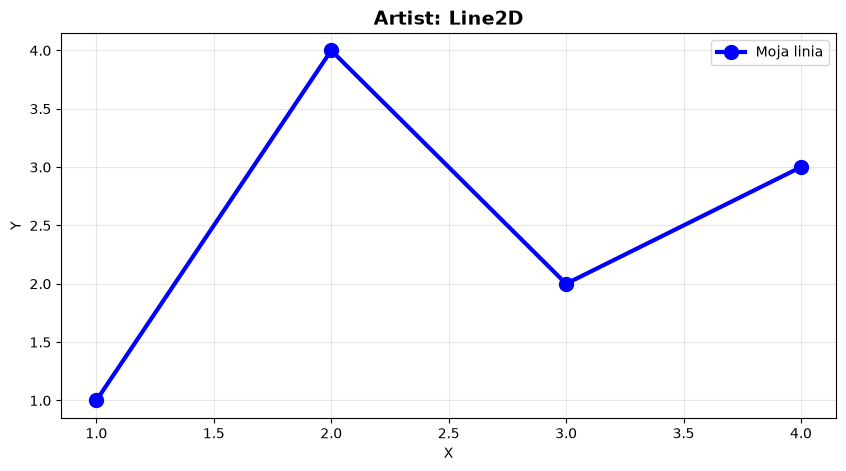

Typ: <class 'matplotlib.lines.Line2D'>
Kolor: blue
Szerokość: 3.0
Styl linii: -
Marker: o

💡 Line2D = linia narysowana przez ax.plot()


In [8]:
# === 1. LINE2D - Linia ===
print("📈 LINE2D - Linia/krzywa\n")

fig, ax = plt.subplots(figsize=(10, 5))

# Tworzymy Line2D
line, = ax.plot([1, 2, 3, 4], [1, 4, 2, 3], 
                color='blue', linewidth=3, marker='o', markersize=10,
                label='Moja linia')

ax.set_title('Artist: Line2D', fontsize=14, fontweight='bold')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.legend()
ax.grid(True, alpha=0.3)

plt.show()

print(f"Typ: {type(line)}")
print(f"Kolor: {line.get_color()}")
print(f"Szerokość: {line.get_linewidth()}")
print(f"Styl linii: {line.get_linestyle()}")
print(f"Marker: {line.get_marker()}")
print(f"\n💡 Line2D = linia narysowana przez ax.plot()")

🟦 PATCH - Wypełnione kształty



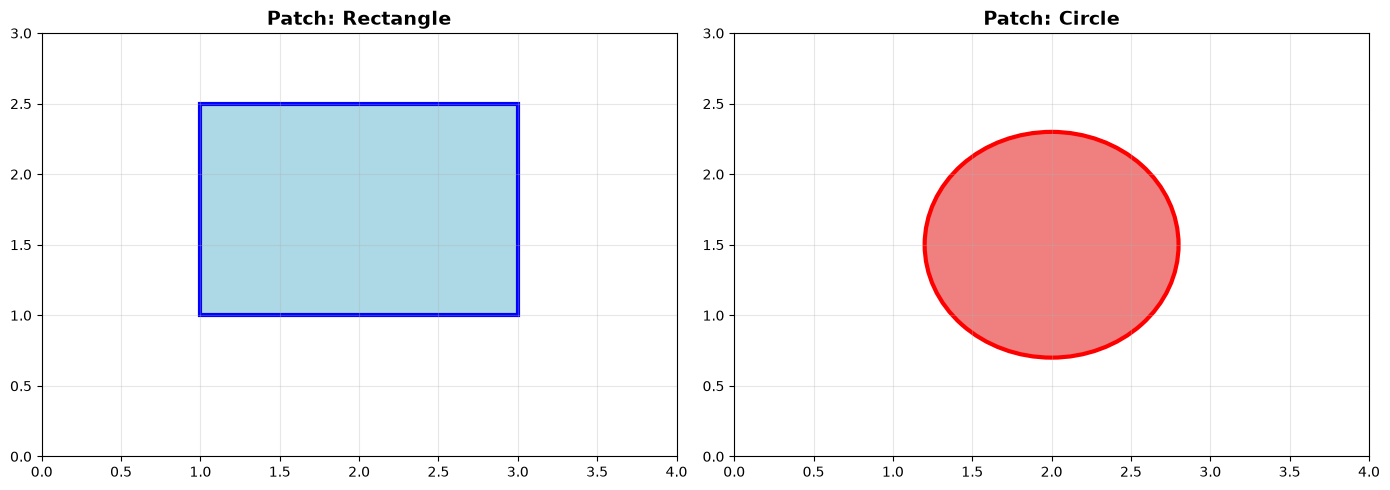

Rectangle typ: <class 'matplotlib.patches.Rectangle'>
Circle typ: <class 'matplotlib.patches.Circle'>

💡 Patch = wypełniony kształt (Rectangle, Circle, Polygon, Wedge...)
   Używane do słupków, kół, wielokątów, itp.


In [9]:
# === 2. PATCH - Wypełniony kształt (Rectangle, Circle, Polygon...) ===
print("🟦 PATCH - Wypełnione kształty\n")

from matplotlib.patches import Rectangle, Circle

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Rectangle ---
ax1 = axes[0]
# Tworzymy prostokąt: (x, y) = lewy dolny róg, width, height
rect = Rectangle((1, 1), width=2, height=1.5, 
                 facecolor='lightblue', edgecolor='blue', linewidth=3)
ax1.add_patch(rect)  # Dodajemy do Axes

ax1.set_xlim(0, 4)
ax1.set_ylim(0, 3)
ax1.set_title('Patch: Rectangle', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)

# --- Circle ---
ax2 = axes[1]
# Tworzymy koło: (x, y) = środek, radius
circle = Circle((2, 1.5), radius=0.8, 
                facecolor='lightcoral', edgecolor='red', linewidth=3)
ax2.add_patch(circle)

ax2.set_xlim(0, 4)
ax2.set_ylim(0, 3)
ax2.set_title('Patch: Circle', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Rectangle typ: {type(rect)}")
print(f"Circle typ: {type(circle)}")
print(f"\n💡 Patch = wypełniony kształt (Rectangle, Circle, Polygon, Wedge...)")
print("   Używane do słupków, kół, wielokątów, itp.")

📝 TEXT - Teksty na wykresie



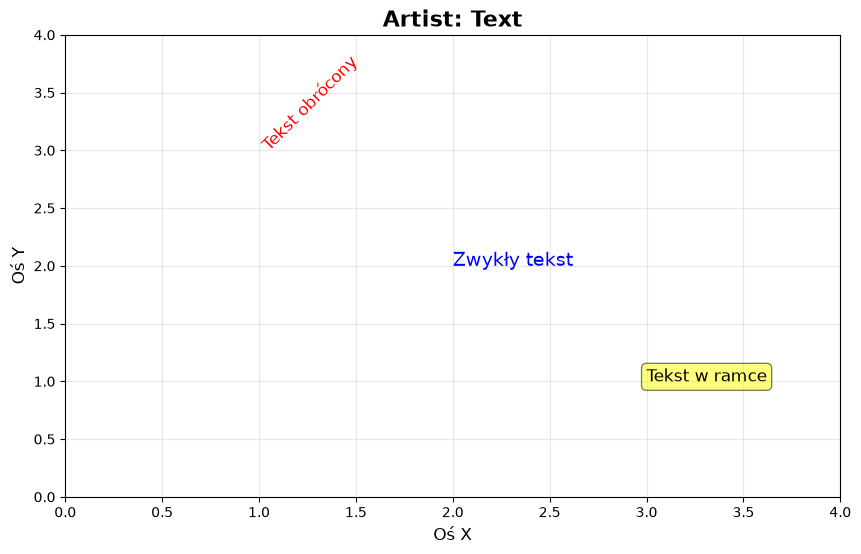

Tytuł typ: <class 'matplotlib.text.Text'>
Xlabel typ: <class 'matplotlib.text.Text'>
Tekst typ: <class 'matplotlib.text.Text'>

💡 Text = każdy tekst na wykresie
   Tytuły, etykiety osi, adnotacje - wszystko to Text!


In [10]:
# === 3. TEXT - Tekst ===
print("📝 TEXT - Teksty na wykresie\n")

fig, ax = plt.subplots(figsize=(10, 6))

# Różne sposoby dodawania tekstu
title = ax.set_title('Artist: Text', fontsize=16, fontweight='bold')
xlabel = ax.set_xlabel('Oś X', fontsize=12)
ylabel = ax.set_ylabel('Oś Y', fontsize=12)

# Tekst w dowolnym miejscu
text1 = ax.text(2, 2, 'Zwykły tekst', fontsize=14, color='blue')
text2 = ax.text(1, 3, 'Tekst obrócony', fontsize=12, rotation=45, color='red')
text3 = ax.text(3, 1, 'Tekst w ramce', fontsize=12, 
                bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.5))

ax.set_xlim(0, 4)
ax.set_ylim(0, 4)
ax.grid(True, alpha=0.3)

plt.show()

print(f"Tytuł typ: {type(title)}")
print(f"Xlabel typ: {type(xlabel)}")
print(f"Tekst typ: {type(text1)}")
print(f"\n💡 Text = każdy tekst na wykresie")
print("   Tytuły, etykiety osi, adnotacje - wszystko to Text!")

#### Przykład kompleksowy - wszystkie Artists razem

🎨 KOMPLEKSOWY WYKRES - Wszystkie typy Artists



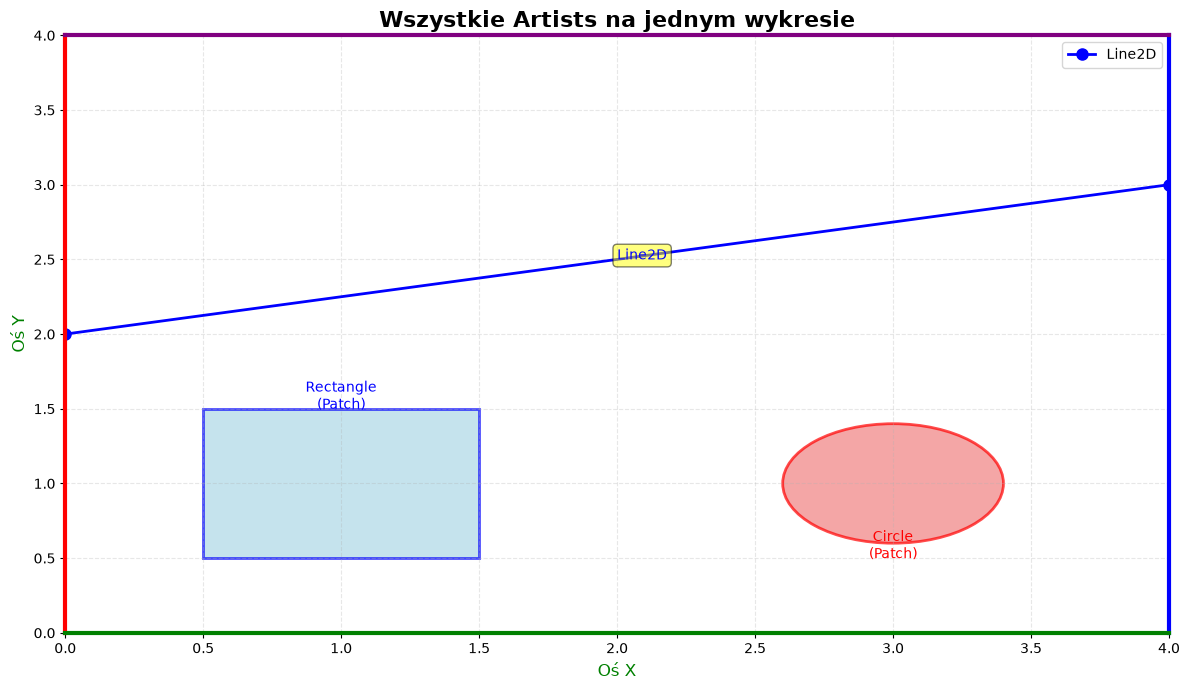

🔍 TYPY ARTISTS NA TYM WYKRESIE:
  1. Figure       = <class 'matplotlib.figure.Figure'>
  2. Axes         = <class 'matplotlib.axes._axes.Axes'>
  3. Line2D       = <class 'matplotlib.lines.Line2D'>
  4. Rectangle    = <class 'matplotlib.patches.Rectangle'>
  5. Circle       = <class 'matplotlib.patches.Circle'>
  6. Text (title) = <class 'matplotlib.text.Text'>
  7. Text (label) = <class 'matplotlib.text.Text'>
  8. Spine (left) = <class 'matplotlib.spines.Spine'>
  9. Legend       = <class 'matplotlib.legend.Legend'>
 10. Axis (X)     = <class 'matplotlib.axis.XAxis'>
 11. Axis (Y)     = <class 'matplotlib.axis.YAxis'>

✅ Widzisz? WSZYSTKO to Artists!


In [11]:
# === KOMPLEKSOWY PRZYKŁAD - Wszystkie Artists razem ===
print("🎨 KOMPLEKSOWY WYKRES - Wszystkie typy Artists\n")

from matplotlib.patches import Rectangle, Circle

fig, ax = plt.subplots(figsize=(12, 7))

# 1. LINE2D - Linia
line, = ax.plot([0, 4], [2, 3], 'b-o', linewidth=2, markersize=8, label='Line2D')

# 2. PATCH - Rectangle
rect = Rectangle((0.5, 0.5), width=1, height=1, 
                 facecolor='lightblue', edgecolor='blue', linewidth=2, alpha=0.7)
ax.add_patch(rect)

# 3. PATCH - Circle  
circle = Circle((3, 1), radius=0.4, 
                facecolor='lightcoral', edgecolor='red', linewidth=2, alpha=0.7)
ax.add_patch(circle)

# 4. TEXT - Różne teksty
title = ax.set_title('Wszystkie Artists na jednym wykresie', fontsize=16, fontweight='bold')
xlabel = ax.set_xlabel('Oś X', fontsize=12, color='green')
ylabel = ax.set_ylabel('Oś Y', fontsize=12, color='green')

text1 = ax.text(1, 1.5, 'Rectangle\n(Patch)', ha='center', fontsize=10, color='blue')
text2 = ax.text(3, 0.5, 'Circle\n(Patch)', ha='center', fontsize=10, color='red')
text3 = ax.text(2, 2.5, 'Line2D', fontsize=10, color='blue',
                bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.5))

# 5. SPINE - Pokolorujmy każdy Spine inaczej
ax.spines['left'].set_color('red')
ax.spines['left'].set_linewidth(3)
ax.spines['right'].set_color('blue')
ax.spines['right'].set_linewidth(3)
ax.spines['bottom'].set_color('green')
ax.spines['bottom'].set_linewidth(3)
ax.spines['top'].set_color('purple')
ax.spines['top'].set_linewidth(3)

# 6. LEGEND
legend = ax.legend(loc='upper right')

ax.set_xlim(0, 4)
ax.set_ylim(0, 4)
ax.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

print("🔍 TYPY ARTISTS NA TYM WYKRESIE:")
print("=" * 70)
print(f"  1. Figure       = {type(fig)}")
print(f"  2. Axes         = {type(ax)}")
print(f"  3. Line2D       = {type(line)}")
print(f"  4. Rectangle    = {type(rect)}")
print(f"  5. Circle       = {type(circle)}")
print(f"  6. Text (title) = {type(title)}")
print(f"  7. Text (label) = {type(xlabel)}")
print(f"  8. Spine (left) = {type(ax.spines['left'])}")
print(f"  9. Legend       = {type(legend)}")
print(f" 10. Axis (X)     = {type(ax.xaxis)}")
print(f" 11. Axis (Y)     = {type(ax.yaxis)}")

print("\n✅ Widzisz? WSZYSTKO to Artists!")

---

### 🎯 Podsumowanie - Artists

**Kluczowe wnioski:**

1. **Wszystko jest Artist-em** - każdy element wizualny dziedziczy po klasie `Artist`
2. **Line2D** = linie/krzywe z `ax.plot()`
3. **Patch** = wypełnione kształty (Rectangle, Circle, Polygon...)
4. **Text** = teksty (tytuły, etykiety, adnotacje)
5. **Spine** = 4 krawędzie wykresu (left, right, top, bottom)
6. **Każdy Artist można modyfikować** - ma metody `get_*()` i `set_*()`

**Praktyczne zastosowanie:**

```python
# Pobierz Artist
line, = ax.plot([1, 2, 3], [1, 2, 3])

# Modyfikuj przez metody
line.set_color('red')
line.set_linewidth(3)
line.set_linestyle('--')

# Albo pobierz wartości
color = line.get_color()
width = line.get_linewidth()
```

**💡 BONUS:** Poniżej znajdziesz wizualizację **wszystkich 12 Artists** z przykładowego wykresu - każdy pokazany osobno w izolacji! Zobaczysz dokładnie z czego składa się "prosty" wykres.

---

### 🔗 Zobacz też

- [Matplotlib - Artist tutorial](https://matplotlib.org/stable/tutorials/intermediate/artists.html)
- Notebook główny: `02_matplotlib_part1.ipynb` - anatomia wykresów

---

### 🔬 BONUS: Wizualizacja WSZYSTKICH Artists z wykresu w izolacji

Zobaczmy każdy z 12 Artists z przykładowego wykresu - każdy osobno!

In [ ]:
# === STWÓRZMY PRZYKŁADOWY WYKRES ===
fig, ax = plt.subplots(figsize=(8, 5))
x = [1, 2, 3, 4, 5]
y = [2, 4, 3, 5, 4]
line, = ax.plot(x, y, marker='o', label='Dane')

ax.set_title('Przykładowy wykres')
ax.set_xlabel('Oś X')
ax.set_ylabel('Oś Y')
ax.legend()
ax.grid(True, alpha=0.3)

plt.show()

print("☝️ To jest nasz przykładowy wykres")
print(f"Teraz rozłożymy go na {len(ax.get_children())} składowych Artists!")

In [ ]:
# === WIZUALIZACJA KAŻDEGO ARTIST OSOBNO ===

# Pobierz wszystkich Artists
artists = ax.get_children()
n_artists = len(artists)

# Stwórz grid 3x4 (12 subplotów)
fig_viz, axes_viz = plt.subplots(3, 4, figsize=(16, 12))
fig_viz.suptitle(f'Wszystkie {n_artists} Artists z wykresu - każdy w izolacji', 
                 fontsize=16, fontweight='bold')

axes_flat = axes_viz.flatten()

# Iteruj po każdym Artist
for i, (artist, ax_viz) in enumerate(zip(artists, axes_flat)):
    artist_type = type(artist).__name__
    
    ax_viz.set_xlim(0, 10)
    ax_viz.set_ylim(0, 10)
    ax_viz.set_aspect('equal')
    ax_viz.set_title(f"#{i+1}: {artist_type}", fontsize=10, fontweight='bold')
    
    try:
        if artist_type == 'Line2D':
            # Narysuj linię
            xdata = artist.get_xdata()
            ydata = artist.get_ydata()
            if len(xdata) > 0:
                x_norm = (xdata - xdata.min()) / (xdata.max() - xdata.min()) * 8 + 1
                y_norm = (ydata - ydata.min()) / (ydata.max() - ydata.min()) * 8 + 1
                ax_viz.plot(x_norm, y_norm, 
                           color=artist.get_color(),
                           linewidth=artist.get_linewidth()*2,
                           linestyle=artist.get_linestyle(),
                           marker=artist.get_marker(),
                           markersize=10)
            
        elif artist_type == 'Spine':
            spine_pos = artist.spine_type
            color = artist.get_edgecolor()
            lw = artist.get_linewidth()
            
            # Rysuj Spine BEZ markerów (marker='')
            if spine_pos == 'left':
                ax_viz.plot([2, 2], [2, 8], color=color, linewidth=lw*3, marker='')
            elif spine_pos == 'right':
                ax_viz.plot([8, 8], [2, 8], color=color, linewidth=lw*3, marker='')
            elif spine_pos == 'bottom':
                ax_viz.plot([2, 8], [2, 2], color=color, linewidth=lw*3, marker='')
            elif spine_pos == 'top':
                ax_viz.plot([2, 8], [8, 8], color=color, linewidth=lw*3, marker='')
            
            ax_viz.text(5, 5, f"'{spine_pos}'", ha='center', fontsize=12)
                
        elif artist_type == 'XAxis' or artist_type == 'YAxis':
            axis_name = 'X' if artist_type == 'XAxis' else 'Y'
            ax_viz.text(5, 5, f"Oś {axis_name}", ha='center', va='center', 
                       fontsize=16, fontweight='bold')
            
            if axis_name == 'X':
                ax_viz.plot([1, 9], [5, 5], 'k-', linewidth=2, marker='')
                ax_viz.plot([9, 8.5], [5, 4.5], 'k-', linewidth=2, marker='')
                ax_viz.plot([9, 8.5], [5, 5.5], 'k-', linewidth=2, marker='')
            else:
                ax_viz.plot([5, 5], [1, 9], 'k-', linewidth=2, marker='')
                ax_viz.plot([5, 4.5], [9, 8.5], 'k-', linewidth=2, marker='')
                ax_viz.plot([5, 5.5], [9, 8.5], 'k-', linewidth=2, marker='')
                
        elif artist_type == 'Text':
            text_str = artist.get_text()
            if text_str:
                ax_viz.text(5, 5, f'"{text_str}"', ha='center', va='center',
                           fontsize=min(artist.get_fontsize(), 14), 
                           color=artist.get_color(),
                           weight=artist.get_weight())
            else:
                ax_viz.text(5, 5, '(pusty)', ha='center', va='center',
                           fontsize=10, style='italic', color='gray')
                
        elif artist_type == 'Rectangle':
            from matplotlib.patches import Rectangle as Rect
            rect = Rect((2, 2), width=6, height=6,
                       facecolor=artist.get_facecolor(),
                       edgecolor=artist.get_edgecolor(),
                       linewidth=artist.get_linewidth()*2)
            ax_viz.add_patch(rect)
            
        elif artist_type == 'Legend':
            ax_viz.text(5, 6, 'Legenda', ha='center', va='center',
                       fontsize=14, fontweight='bold')
            texts = artist.get_texts()
            if texts:
                labels = [t.get_text() for t in texts]
                ax_viz.text(5, 4, '\n'.join(labels), ha='center', fontsize=10)
                
        else:
            ax_viz.text(5, 5, artist_type, ha='center', va='center',
                       fontsize=12, fontweight='bold')
            
    except Exception as e:
        ax_viz.text(5, 5, artist_type, ha='center', va='center',
                   fontsize=10, color='red')
    
    # Wyłącz osie, ticke i spines - CZYSTY subplot
    ax_viz.set_xticks([])
    ax_viz.set_yticks([])
    ax_viz.tick_params(left=False, right=False, top=False, bottom=False,
                       labelleft=False, labelright=False, labeltop=False, labelbottom=False)
    for spine in ax_viz.spines.values():
        spine.set_visible(False)

plt.tight_layout()
plt.show()

print(f"\n✅ Każdy z {n_artists} Artists wyświetlony osobno!")
print("\n💡 Lista wszystkich Artists:")
for i, artist in enumerate(artists):
    print(f"  #{i+1:2d}. {type(artist).__name__}")

**Co widzimy na tych 12 subplotach?**

1. **#1: Line2D** - nasza linia danych (z markerami 'o')
2. **#2-5: Spine** - 4 krawędzie wykresu (left, right, bottom, top)
3. **#6: XAxis** - oś X z podziałkami i etykietami
4. **#7: YAxis** - oś Y z podziałkami i etykietami  
5. **#8-10: Text** - tytuł, xlabel, ylabel
6. **#11: Rectangle** - tło wykresu (patch)
7. **#12: Legend** - legenda z napisem "Dane"

**Wniosek:** Nawet "prosty" wykres to złożona hierarchia 12 obiektów! Każdy ma swoje właściwości i można go modyfikować osobno. 🎨

---

## 3. Co oznacza figsize i DPI? Jak wykres wyświetla się na ekranie?

### 🎯 Krótka odpowiedź

**`figsize=(12, 5)`** = rozmiar wykresu: **12 cali szerokości × 5 cali wysokości**

**`dpi=100`** = **100 pikseli na cal** (gęstość pikseli)

**Rozmiar w pikselach** = `figsize × dpi` = 1200×500 px (rozdzielczość obrazu)

---

### 📚 Szczegółowe wyjaśnienie

⚠️ **WAŻNE:** Parametry `figsize` i `dpi` działają **inaczej** w zależności od zastosowania (ekran vs druk)!

---

#### **📌 DPI vs PPI - co to właściwie znaczy?**

Zanim przejdziemy dalej, musimy wyjaśnić **kluczową różnicę** między DPI a PPI, bo matplotlib używa parametru `dpi`, ale **nie zawsze oznacza to to samo!**

---

**🖨️ DPI (Dots Per Inch) = kropki drukarki na cal**

- **Gdzie:** Drukowanie fizyczne (drukarki, prasa)
- **Co:** Ile **kropek tuszu/tonera** drukarka może położyć na 1 calu papieru
- **Przykład:** Drukarka 1200 DPI = 1200 kropek tuszu na 1 cal
- **Kontekst:** Hardware drukarki (fizyczna gęstość kropek)

**Typowe wartości:**
- 300-600 DPI - druk domowy
- 1200-2400 DPI - druk profesjonalny
- 4800+ DPI - druk fotograficzny

---

**🖥️ PPI (Pixels Per Inch) = piksele na cal**

- **Gdzie:** Obrazy cyfrowe, ekrany
- **Co:** Ile **pikseli** (kwadracików obrazu) mieści się na 1 calu
- **Przykład:** Obraz 300 PPI = 300 pikseli na 1 cal obrazu
- **Kontekst:** Rozdzielczość obrazów cyfrowych (PNG, JPG, ekrany)

**Typowe wartości:**
- 72-96 PPI - obrazy ekranowe (web, Jupyter)
- 150-200 PPI - prezentacje
- 300 PPI - standard dla obrazów do druku (magazyny, publikacje)
- 227+ PPI - ekrany Retina (bardzo ostre)

---

**🤔 Dlaczego w matplotlib to nieoczywiste?**

**Problem:** Matplotlib używa parametru **`dpi`**, ale w rzeczywistości chodzi o **PPI** (piksele na cal), nie DPI (kropki drukarki)!

```python
fig, ax = plt.subplots(figsize=(6, 4), dpi=100)
# ⚠️ Parametr nazywa się 'dpi', ale...
# Matplotlib tworzy OBRAZ o rozdzielczości 600×400 PIKSELI
# Więc faktycznie to: 100 PIKSELI na cal = 100 PPI!
```

**Dlaczego tak?**

1. **Historyczne nazewnictwo** - matplotlib został stworzony w 2003, gdy terminy DPI/PPI były używane zamiennie
2. **Parametr `dpi`** określa **rozdzielczość obrazu cyfrowego** (w pikselach), nie gęstość kropek drukarki
3. **Technicznie poprawne:** powinno być `ppi`, ale zostało `dpi` (z powodów historycznych)

**Konsekwencja:**

| Co robi matplotlib | Poprawne określenie | Co matplotlib używa |
|-------------------|---------------------|---------------------|
| Tworzy obraz w pikselach | PPI (pixels-per-inch) | ❌ **`dpi`** (mylące!) |
| Zapisuje metadane do pliku | PPI (rozdzielczość obrazu) | ✅ zapisuje jako "dpi" w PNG/PDF |
| Oblicza rozmiar: figsize × wartość | **100 pikseli na cal** | `dpi=100` |

**💡 Zapamiętaj:**

Gdy widzisz w matplotlib **`dpi=100`**, myśl: **"100 pikseli na cal obrazu" (PPI)**, nie "100 kropek drukarki" (DPI hardware).

**Realne DPI drukarki** (np. 1200 DPI) to osobna wartość - to gęstość fizycznych kropek tuszu, którą drukarka użyje podczas drukowania Twojego obrazu.

**Wniosek:** `dpi` w matplotlib = rozdzielczość obrazu w **pikselach na cal** (PPI), a nie fizyczne DPI drukarki.

---

#### **Zastosowanie 1: Wyświetlanie na ekranie (Jupyter, przeglądarka)**

**Cel:** Wygenerować obraz o określonej **liczbie pikseli**

```python
fig, ax = plt.subplots(figsize=(6, 4), dpi=100)
# Tworzy bitmap: 600×400 pikseli
```

**Wzór:**
```
Szerokość w px = figsize[0] × dpi = 6 × 100 = 600 px
Wysokość w px = figsize[1] × dpi = 4 × 100 = 400 px
```

**Jak to działa:**
1. Matplotlib tworzy **bitmap (obraz rastrowy)** o rozmiarze `figsize × dpi` pikseli
2. Jupyter/przeglądarka wyświetla ten bitmap **1:1** (1 piksel obrazu = 1 piksel ekranu)
3. **Tylko iloczyn się liczy!**

**Konsekwencja:**
```python
figsize=(6, 4), dpi=150  → 900×600 px
figsize=(9, 6), dpi=100  → 900×600 px  # IDENTYCZNE na ekranie!
```

Na ekranie wyglądają **identycznie**, bo mają ten sam rozmiar w pikselach.

**Typowe wartości dla ekranu:**

| figsize | dpi | Rozmiar px | Zastosowanie |
|---------|-----|------------|--------------|
| (10, 5) | 72  | 720×360 px | Mały wykres |
| (10, 5) | 100 | 1000×500 px | **Standard (domyślne)** |
| (12, 6) | 100 | 1200×600 px | Większy wykres |

---

### 💻 Przykłady praktyczne - jak figsize i dpi wpływają na rozmiar

Zobaczmy na żywych przykładach jak zmiana `figsize` i `dpi` wpływa na rozmiar obrazu w pikselach.

🎯 PUNKT WYJŚCIA - bazowy przykład



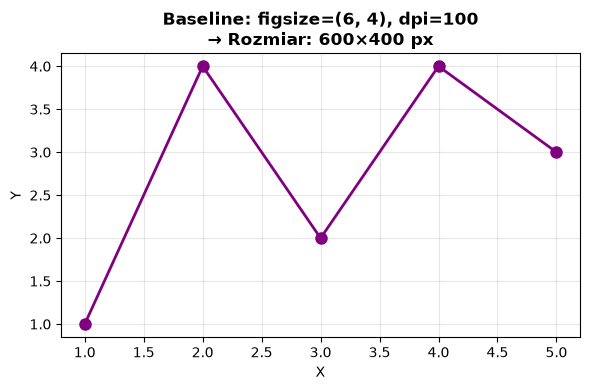

📐 Obliczenia:
   Szerokość: 6 cali × 100 dpi = 600 px
   Wysokość:  4 cale × 100 dpi = 400 px

💡 To jest nasz punkt odniesienia!
   Teraz zobaczmy co się stanie gdy zmienimy dpi lub figsize...


In [3]:
# === PUNKT WYJŚCIA: figsize=(6, 4), dpi=100 ===
print("🎯 PUNKT WYJŚCIA - bazowy przykład\n")

fig, ax = plt.subplots(figsize=(6, 4), dpi=100)
ax.plot([1, 2, 3, 4, 5], [1, 4, 2, 4, 3], 'o-', linewidth=2, markersize=8, color='purple')
ax.set_title('Baseline: figsize=(6, 4), dpi=100\n→ Rozmiar: 600×400 px', 
             fontsize=12, fontweight='bold')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("📐 Obliczenia:")
print(f"   Szerokość: 6 cali × 100 dpi = {6 * 100} px")
print(f"   Wysokość:  4 cale × 100 dpi = {4 * 100} px")
print(f"\n💡 To jest nasz punkt odniesienia!")
print("   Teraz zobaczmy co się stanie gdy zmienimy dpi lub figsize...")

🔄 EKSPERYMENT 1: Ta sama figsize=(6, 4), różne dpi



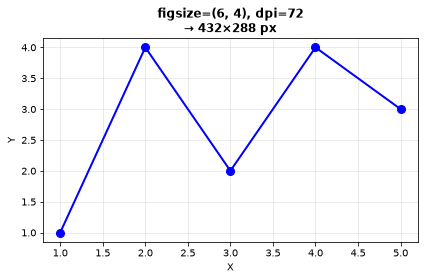

✅ Wykres 72 DPI: rozmiar obrazu = 432×288 px
   (figsize=(6, 4) × dpi=72)



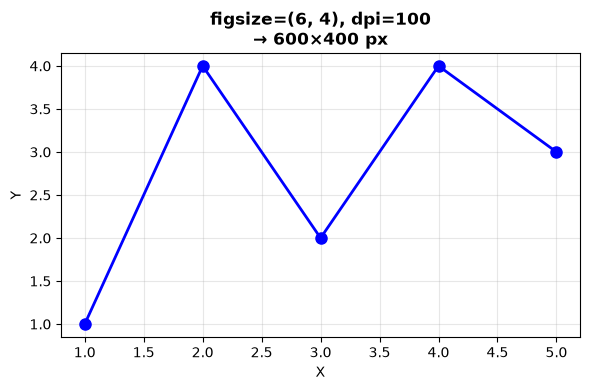

✅ Wykres 100 DPI: rozmiar obrazu = 600×400 px
   (figsize=(6, 4) × dpi=100)



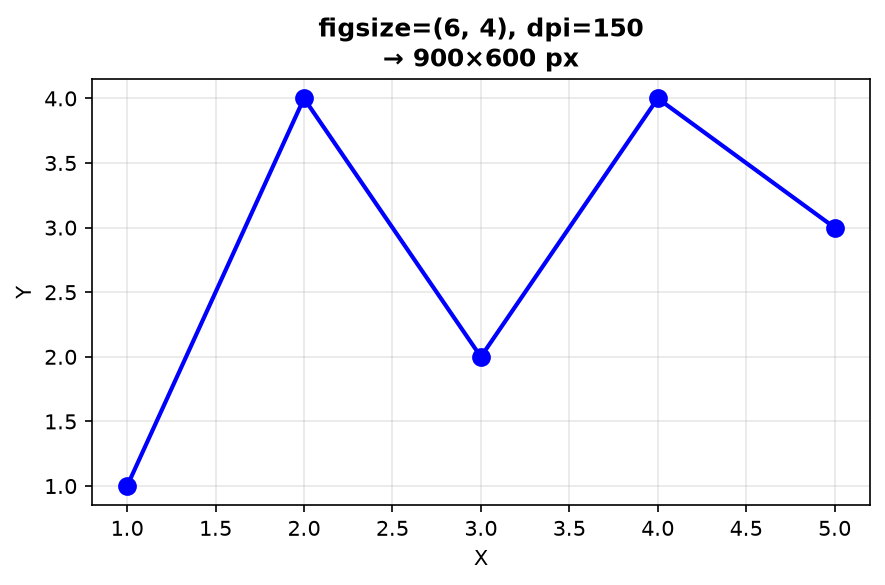

✅ Wykres 150 DPI: rozmiar obrazu = 900×600 px
   (figsize=(6, 4) × dpi=150)

💡 WNIOSEK: Większe dpi → więcej pikseli → większy/ostrzejszy obraz!
   (6,4) × 72 dpi  = 432×288 px   ← mały
   (6,4) × 100 dpi = 600×400 px ← średni
   (6,4) × 150 dpi = 900×600 px ← duży


In [6]:
# === EKSPERYMENT 1: Ta sama figsize, różne dpi ===
print("🔄 EKSPERYMENT 1: Ta sama figsize=(6, 4), różne dpi\n")

dpi_values = [72, 100, 150]

# Tworzymy 3 OSOBNE FIGURY - każda z innym DPI
for dpi_val in dpi_values:
    fig, ax = plt.subplots(figsize=(6, 4), dpi=dpi_val)
    
    # Prościutki wykres - linia
    ax.plot([1, 2, 3, 4, 5], [1, 4, 2, 4, 3], 'o-', linewidth=2, markersize=8, color='blue')
    
    # Oblicz rozmiar w pikselach
    px_width = 6 * dpi_val
    px_height = 4 * dpi_val
    
    # Tytuł z informacją
    ax.set_title(f'figsize=(6, 4), dpi={dpi_val}\n→ {px_width}×{px_height} px', 
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print(f"✅ Wykres {dpi_val} DPI: rozmiar obrazu = {px_width}×{px_height} px")
    print(f"   (figsize={(6, 4)} × dpi={dpi_val})\n")

print("=" * 70)
print("💡 WNIOSEK: Większe dpi → więcej pikseli → większy/ostrzejszy obraz!")
print(f"   (6,4) × 72 dpi  = {6*72}×{4*72} px   ← mały")
print(f"   (6,4) × 100 dpi = {6*100}×{4*100} px ← średni")
print(f"   (6,4) × 150 dpi = {6*150}×{4*150} px ← duży")
print("=" * 70)

🔄 EKSPERYMENT 2: To samo dpi=100, różne figsize



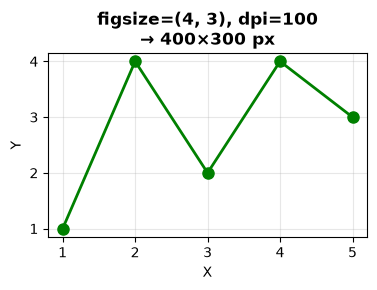

✅ Wykres figsize=(4, 3): rozmiar obrazu = 400×300 px
   (figsize=({4}, {3}) × dpi=100)



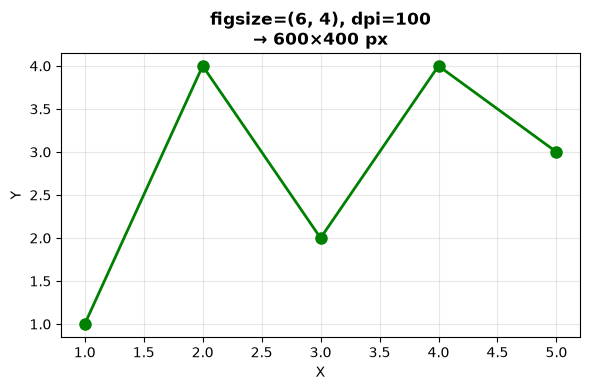

✅ Wykres figsize=(6, 4): rozmiar obrazu = 600×400 px
   (figsize=({6}, {4}) × dpi=100)



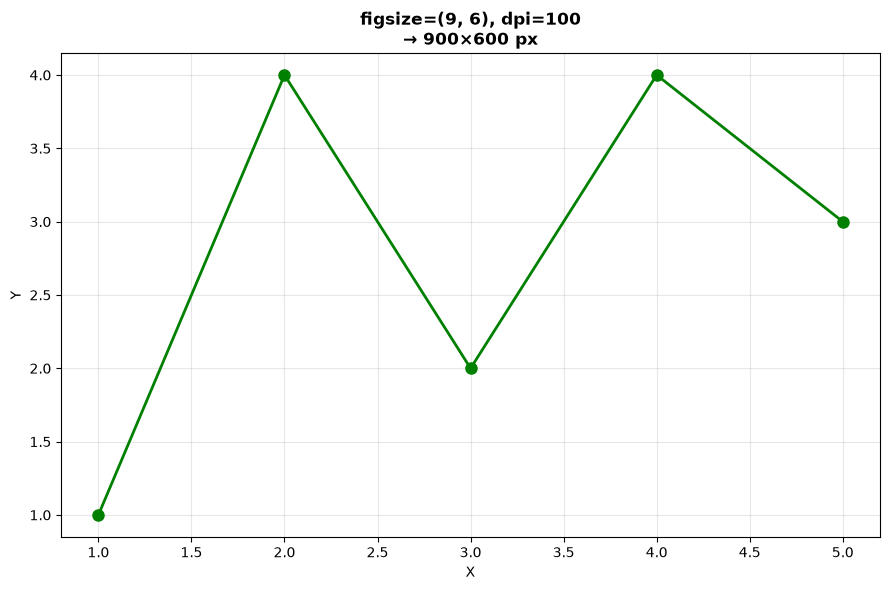

✅ Wykres figsize=(9, 6): rozmiar obrazu = 900×600 px
   (figsize=({9}, {6}) × dpi=100)

💡 WNIOSEK: Większe figsize (w calach) → więcej pikseli → większy obraz!
   (4,3) × 100 dpi = 400×300 px   ← mały
   (6,4) × 100 dpi = 600×400 px   ← średni
   (8,6) × 100 dpi = 800×600 px   ← duży


In [7]:
# === EKSPERYMENT 2: To samo dpi, różne figsize ===
print("🔄 EKSPERYMENT 2: To samo dpi=100, różne figsize\n")

figsizes = [(4, 3), (6, 4), (9, 6)]

# Tworzymy 3 OSOBNE FIGURY - każda z innym figsize
for w, h in figsizes:
    fig, ax = plt.subplots(figsize=(w, h), dpi=100)
    
    # Prościutki wykres - linia
    ax.plot([1, 2, 3, 4, 5], [1, 4, 2, 4, 3], 'o-', linewidth=2, markersize=8, color='green')
    
    # Oblicz rozmiar w pikselach
    px_width = w * 100
    px_height = h * 100
    
    # Tytuł z informacją
    ax.set_title(f'figsize=({w}, {h}), dpi=100\n→ {px_width}×{px_height} px', 
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print(f"✅ Wykres figsize=({w}, {h}): rozmiar obrazu = {px_width}×{px_height} px")
    print(f"   (figsize={({w}, {h})} × dpi=100)\n")

print("=" * 70)
print("💡 WNIOSEK: Większe figsize (w calach) → więcej pikseli → większy obraz!")
print(f"   (4,3) × 100 dpi = {4*100}×{3*100} px   ← mały")
print(f"   (6,4) × 100 dpi = {6*100}×{4*100} px   ← średni")
print(f"   (8,6) × 100 dpi = {8*100}×{6*100} px   ← duży")
print("=" * 70)

#### **Zastosowanie 2: Drukowanie (PDF, PNG do wydruku)**

**Cel:** Określić **fizyczny rozmiar na papierze**

```python
fig, ax = plt.subplots(figsize=(6, 4), dpi=300)
# Obraz 1800×1200 px z metadanymi: "wydrukuj jako 6×4 cale"
```

**Jak to działa:**
1. Matplotlib tworzy obraz o rozmiarze `figsize × dpi` pikseli (np. 1800×1200 px)
2. W pliku PNG/PDF zapisuje **metadane DPI** (np. 300)
3. Program graficzny/drukarka czyta metadane i oblicza fizyczny rozmiar:
   ```
   Szerokość fizyczna = piksele ÷ dpi = 1800 px ÷ 300 = 6 cali
   Wysokość fizyczna = piksele ÷ dpi = 1200 px ÷ 300 = 4 cale
   ```
4. Drukarka (z własnym **DPI drukarki** np. 1200) drukuje obraz na tym obszarze

**Konsekwencja:**
```python
figsize=(6, 4), dpi=150  → 900×600 px → wydruk 6×4 cale (150 px/cal)
figsize=(9, 6), dpi=100  → 900×600 px → wydruk 9×6 cali (100 px/cal)
```

Mimo tego samego rozmiaru w pikselach (900×600), **fizyczny rozmiar wydruku jest różny!**

**Uwaga o DPI:**
- **DPI obrazu** (matplotlib, np. 300) = metadane mówiące "wydrukuj ten obraz jako X cali"
- **DPI drukarki** (hardware, np. 1200) = ile kropek tuszu drukarka może położyć na cal
- **To są dwie różne wartości!** DPI obrazu - na jej podstawie wyliczany jest rozmiar wydruku (wyrażony w calach jako stosunek rozdzielczości obrazu do dpi), DPI drukarki określa jak dużo kropek tuszu będzie użyte

**Typowe wartości dla druku:**

| figsize | dpi | Rozmiar px | Fizyczny rozmiar | Jakość |
|---------|-----|------------|------------------|---------|
| (8, 6) | 150 | 1200×900 px | 8×6 cali | Prezentacja |
| (8, 6) | 300 | 2400×1800 px | 8×6 cali | **Wysokiej jakości druk** |
| (8, 6) | 600 | 4800×3600 px | 8×6 cali | Druk profesjonalny |

---

#### **Zastosowanie 3: Proporcje elementów wewnętrznych**

**Cel:** Określić **względne rozmiary** czcionek, linii, markerów

```python
fig, ax = plt.subplots(figsize=(6, 4))
ax.set_title('Tytuł', fontsize=12)  # 12 punktów = 12/72 cala ≈ 0.167"
```

**Jak to działa:**
- `fontsize=12` = 12 punktów typograficznych = **0.167 cala**
- Na wykresie `figsize=(6, 4)`: 0.167" / 6" = **2.8% szerokości**
- Na wykresie `figsize=(9, 6)`: 0.167" / 9" = **1.9% szerokości**

**Konsekwencja:**
Nawet przy tym samym rozmiarze w pikselach (900×600 px):
- `figsize=(6,4)`: elementy **większe względem całości** (2.8%)
- `figsize=(9,6)`: elementy **mniejsze względem całości** (1.9%)

**Matplotlib oblicza proporcje względem `figsize`, nie względem pikseli!**

---

### 💡 Podsumowanie

| Zastosowanie | Rola `figsize` | Rola `dpi` | Co się liczy |
|--------------|----------------|------------|--------------|
| **Ekran** | Składnik iloczynu | Składnik iloczynu | **Tylko iloczyn** (piksele) |
| **Druk** | Docelowy rozmiar fizyczny | Metadane skalowania | **Oba osobno** |
| **Proporcje** | Układ współrzędnych | (nie ma znaczenia) | **Tylko figsize** |

**Przykład kluczowy:**
```python
figsize=(6,4) dpi=150  # → 900×600 px
figsize=(9,6) dpi=100  # → 900×600 px
```

✅ **Na ekranie:** identyczne (ten sam rozmiar w px)  
❌ **Przy druku:** różne (6×4" vs 9×6" fizycznie)  
❌ **Proporcje elementów:** różne (większe vs mniejsze)

---

#### **3. PPI fizyczne ekranu - ile pikseli w calu ekranu**

**PPI fizyczne ekranu** = ile **fizycznych pikseli** ekranu mieści się w 1 **calu fizycznej szerokości/wysokości**

**Mierzone w linii prostej** (poziomo lub pionowo):

**Wzór:**
```
PPI ekranu = rozdzielczość_px / rozmiar_fizyczny_w_calach
```

**Przykłady monitorów:**

| Monitor | Rozdzielczość | Przekątna | Szerokość | PPI |
|---------|---------------|-----------|-----------|-----|
| 24" Full HD | 1920×1080 px | 24" | ~20.9" | **~92 PPI** |
| 27" 4K | 3840×2160 px | 27" | ~23.5" | **~163 PPI** |
| 13" MacBook Retina | 2560×1600 px | 13" | ~11.3" | **~227 PPI** (bardzo ostry!) |

**Interpretacja:**
- **Niskie PPI (<100):** Ziarnisty obraz (Full HD na dużym ekranie)
- **Średnie PPI (100-150):** Standardowa jakość
- **Wysokie PPI (>200):** Bardzo ostry obraz (Retina, 4K na małym ekranie)

**Uwaga:** Często spotyka się określenie "DPI ekranu", ale technicznie poprawne jest **PPI** (pixels-per-inch), bo ekrany wyświetlają piksele, nie kropki drukarki.

---

#### **4. Rozdzielczość FIZYCZNA vs SYSTEMOWA**

**Monitor ma stałą rozdzielczość fizyczną (hardware):**

Monitor **24" Full HD** ma **dokładnie 1920×1080 fizycznych pikseli** (diody LED). **Tego nie można zmienić!**

**System pozwala ustawić różne rozdzielczości (software):**

W systemie możesz ustawić np. 1280×720 zamiast natywnej 1920×1080.

**Co się dzieje?**
```
Aplikacja rysuje → Bufor wirtualny: 1280×720 px
         ↓
    SKALOWANIE (interpolacja)
         ↓
Monitor fizyczny: 1920×1080 px
```

**Efekt:**
- 1 "wirtualny piksel" = 1.5 fizycznego piksela
- Obraz **rozmazany** (interpolacja)
- Wszystko **większe** (mniej mieści się na ekranie)

**HiDPI Scaling (nowoczesne systemy):**

Ekran 4K (3840×2160) na 24" = 184 PPI → wszystko **maleńkie!**

**Rozwiązanie:** Display scaling 150%
```
Aplikacje "widzą": 2560×1440 px (wirtualne)
         ↓
System renderuje: 3840×2160 px (fizyczne)
         ↓
1.5 fizycznego piksela = 1 logiczny piksel
```

**Efekt:** Normalny rozmiar UI + super ostrość!

---

#### **5. Jak matplotlib wyświetla się na ekranie?**

**Krok 1: Matplotlib generuje obraz**
```python
fig, ax = plt.subplots(figsize=(10, 5), dpi=100)
# Generuje obraz: 1000×500 px (10 × 100 = 1000, 5 × 100 = 500)
```

**Krok 2: Wyświetlenie na różnych ekranach**

Plik graficzny: **1000×500 px**

**Bez skalowania (1:1):** 1 piksel pliku = 1 piksel ekranu

| Ekran | PPI ekranu | Pikseli zajmuje | Fizyczny rozmiar |
|-------|------------|-----------------|------------------|
| 24" Full HD | 92 PPI | 1000×500 px | **10.9×5.4 cala** |
| 27" 4K | 163 PPI | 1000×500 px | **6.1×3.1 cala** |
| MacBook Retina | 227 PPI | 1000×500 px | **4.4×2.2 cala** (mały!) |

**W Jupyter Notebook:**

Jupyter **próbuje** respektować `figsize`, ale często wyświetla 1:1 (bez skalowania).

**Wniosek:**
- **Wysoki PPI ekranu** → ten sam obraz zajmuje **mniej miejsca fizycznie**
- **Niski PPI ekranu** → ten sam obraz zajmuje **więcej miejsca fizycznie**

---

### 🎯 Podsumowanie - wszystko razem

```python
fig, ax = plt.subplots(figsize=(10, 5), dpi=100)
```

**Co się dzieje:**

1. **Matplotlib tworzy obraz:** (10 cali × 5 cali) $\cdot$ 100 dpi = **1000×500 px**
2. **Plik graficzny:** PNG/JPG o rozmiarze 1000×500 pikseli
3. **Wyświetlenie na ekranie 92 PPI (bez skalowania):**
   - Zajmuje: 1000 px / 92 PPI ≈ **10.9 cala** szerokości ekranu
4. **Wyświetlenie na Retina 227 PPI:**
   - Zajmuje: 1000 px / 227 PPI ≈ **4.4 cala** szerokości (znacznie mniej!)

**Praktyczne zastosowania:**

```python
# Standardowy wykres do Jupyter
fig, ax = plt.subplots(figsize=(12, 6), dpi=100)  # 1200×600 px

# Duży wykres do prezentacji
fig, ax = plt.subplots(figsize=(16, 9), dpi=150)  # 2400×1350 px

# Wykres do druku
fig, ax = plt.subplots(figsize=(8, 6), dpi=300)   # 2400×1800 px (wysoka jakość druku!)

# Mały wykres (thumbnail)
fig, ax = plt.subplots(figsize=(4, 3), dpi=72)    # 288×216 px
```

---

### 💡 Najważniejsze wnioski

1. **`figsize`** = rozmiar w calach (szerokość, wysokość)
2. **`dpi` w matplotlib** = parametr określający ile pikseli w 1 calu obrazu (technicznie PPI)
3. **Rozmiar w pikselach** = `figsize × dpi`
4. **PPI ekranu** = ile fizycznych pikseli ekranu w 1 calu
5. **Fizyczny rozmiar na ekranie** = `piksele_obrazu / PPI_ekranu`
6. **Retina/4K** = wysoki PPI → ten sam obraz wygląda mniejszy fizycznie

**🔑 KLUCZOWY WNIOSEK (patrz Eksperyment 3):**

**`figsize=(6,4) dpi=150`** i **`figsize=(9,6) dpi=100`** dają **ten sam rozmiar w pikselach** (900×600 px), ale:
- **Na ekranie:** wyglądają identycznie
- **Proporcje elementów:** różne! Matplotlib oblicza rozmiary czcionek, linii, markerów **względem figsize**
  - figsize=(6,4): elementy większe względem całości
  - figsize=(9,6): elementy mniejsze względem całości
- **Przy drukowaniu:** różny fizyczny rozmiar na papierze (6×4" vs 9×6")

**Różnica PPI vs DPI:**
- **PPI (pixels-per-inch)** = piksele na cal → ekrany, obrazy cyfrowe
- **DPI (dots-per-inch)** = kropki drukarki na cal → druk fizyczny
- Matplotlib używa parametru `dpi`, ale faktycznie chodzi o PPI (piksele)

---

### 🔗 Zobacz też

- [Matplotlib - Figure size and DPI](https://matplotlib.org/stable/gallery/subplots_axes_and_figures/figure_size_units.html)
- [PPI vs DPI - What's the difference?](https://99designs.com/blog/tips/ppi-vs-dpi-whats-the-difference/)
- Notebook główny: `02_matplotlib_part1.ipynb` - pierwsze przykłady z `figsize`

---

## 4. Czym jest backend i dlaczego matplotlib nie wyświetla wykresów w skrypcie?

### 🎯 Krótka odpowiedź

**Backend** = silnik renderowania matplotlib, który określa **jak** i **gdzie** wykresy są wyświetlane.

**Problem:** Gdy uruchamiasz `plt.show()` w skrypcie Python i **nic się nie dzieje** - to znaczy że masz **nieinteraktywny backend** (np. `Agg`), który służy tylko do zapisu plików, nie do wyświetlania okien.

**Rozwiązanie:** Ustaw **interaktywny backend** przed importem pyplot:
```python
import matplotlib
matplotlib.use('TkAgg')  # lub 'Qt5Agg', 'WebAgg', ... (większość wymaga doinstalowania zewnętrznych pakietów)
import matplotlib.pyplot as plt
```

---

### 📚 Szczegółowe wyjaśnienie

#### **Czym jest backend?**

Backend to **warstwa renderowania** matplotlib - odpowiada za:
1. **Renderowanie wykresu** (przekształcenie danych → obraz)
2. **Wyświetlanie** (okno GUI) lub **zapis do pliku** (PNG, PDF, SVG)
3. **Obsługę interakcji** (zoom, pan, kliknięcia myszy)

**Matplotlib ma wiele backendów** - każdy do innego celu!

---

### 📦 Kategorie backendów

Matplotlib dzieli backendy na kilka kategorii:

#### **1. Nieinteraktywne (non-interactive) - tylko zapis do pliku**

Służą **wyłącznie do generowania plików** - nie mogą wyświetlać okien GUI.

| Backend | Format wyjściowy | Instalacja |
|---------|------------------|------------|
| **`agg`** | PNG, JPG | ✅ Zawsze dostępny (domyślny) |
| `cairo` | PNG, PDF, SVG | Wymaga: `cairo` (systemowy) |
| `pdf` | PDF | ✅ Zawsze dostępny |
| `svg` | SVG | ✅ Zawsze dostępny |
| `ps` | PostScript | ✅ Zawsze dostępny |

**Użycie:**
```python
import matplotlib
matplotlib.use('agg')  # Ustaw przed import pyplot!
import matplotlib.pyplot as plt

plt.plot([1, 2, 3], [1, 4, 9])
plt.savefig('wykres.png')  # Zapisz do pliku
# plt.show()  # ❌ NIE ZADZIAŁA - Agg jest nieinteraktywny!
```

**⚠️ Backend `agg` jako domyślny fallback:**

Jeśli matplotlib **nie wykryje żadnych interaktywnych backendów** (TkAgg, Qt5Agg, etc.), automatycznie użyje **`agg`** jako domyślnego.

Gdy próbujesz wtedy użyć `plt.show()`, zobaczysz ostrzeżenie:

```
UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()
```

**Co to oznacza?**
- Backend `agg` **nie może wyświetlać okien GUI** (jest nieinteraktywny)
- `plt.show()` nie wyświetli wykresu, ale też **nie zapisze go do pliku**
- Wykres jest tylko renderowany w pamięci (bufor)

**Rozwiązanie:**
```python
# Opcja 1: Zainstaluj interaktywny backend
sudo apt install python3-tk  # TkAgg
# lub: pip install PyQt5      # Qt5Agg

# Opcja 2: Użyj WebAgg (nie wymaga instalacji)
import matplotlib
matplotlib.use('WebAgg')
import matplotlib.pyplot as plt

# Opcja 3: Zapisz do pliku zamiast wyświetlać
plt.plot([1, 2, 3])
plt.savefig('wykres.png')  # Zamiast plt.show()
```

**Kiedy używać:**
- Generowanie wykresów na serwerach (bez GUI)
- Automatyczne raporty
- Docker containers
- SSH / headless environments

---

#### **2. GUI backendy (interactive) - wymagają bibliotek systemowych**

Wyświetlają wykresy w **oknie graficznym** - wymagają zainstalowania bibliotek GUI.

| Backend | GUI Library | Instalacja | Dostępność w pip |
|---------|-------------|------------|-------------------|
| **`TkAgg`** | TkInter | `sudo apt install python3-tk` | ❌ **NIE** - tylko przez menedżer systemowy |
| **`Qt5Agg`** | PyQt5 | `pip install PyQt5` | ✅ **TAK** |
| `QtAgg` | PyQt6 | `pip install PyQt6` | ✅ TAK |
| `GTK3Agg` | GTK+ 3.0 | `sudo apt install python3-gi` | ❌ NIE |
| `GTK4Agg` | GTK 4.0 | `sudo apt install python3-gi` | ❌ NIE |
| `WXAgg` | wxPython | `pip install wxPython` | ✅ TAK |
| `macosx` | Cocoa (macOS) | ✅ Wbudowany w macOS | N/A |

**⚠️ Uwaga o TkInter:**
- **TkInter** jest częścią standardowej biblioteki Pythona, ALE...
- **NIE jest dystrybuowany przez pip!**
- Musisz zainstalować przez **menedżer pakietów systemowych**:
  ```bash
  # Ubuntu/Debian
  sudo apt install python3-tk
  
  # Fedora/RHEL  
  sudo dnf install python3-tkinter
  
  # Arch Linux
  sudo pacman -S tk
  ```
  
- **Podczas instalacji Pythona z instalatora Windows:** TkInter jest **opcjonalny** - musisz zaznaczyć w wizard:


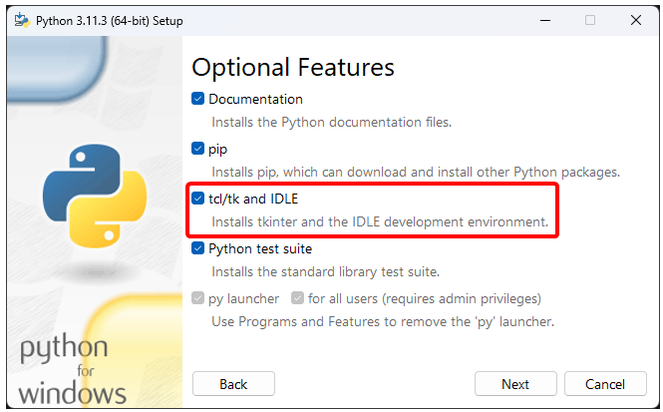

*Podczas instalacji Pythona zaznacz "tcl/tk and IDLE" aby zainstalować TkInter*


**Środowiska wirtualne i TkInter:**
- Gdy uruchamiasz `python -m venv myenv`, środowisko wirtualne **NIE dziedziczy** pakietów zainstalowanych przez `apt`/`dnf`
- Ale TkInter jest **wyjątkiem** - venv **widzi systemowy TkInter**! (bo to rozszerzenie C Pythona, nie pakiet pip)
- Nie musisz ustawiać `--system-site-packages`

**Użycie:**
```python
import matplotlib
matplotlib.use('TkAgg')  # ⬅️ MUSI BYĆ przed import pyplot!
import matplotlib.pyplot as plt

plt.plot([1, 2, 3], [1, 4, 9])
plt.show()  # ✅ Otwiera okno GUI!
```

**Który backend GUI wybrać?**
- **TkAgg** - jeśli masz zainstalowany `python3-tk` (wbudowany w Pythona na Windows)
- **Qt5Agg** - łatwa instalacja przez pip (`pip install PyQt5`)
- **GTK3Agg** - jeśli używasz środowiska GNOME/GTK (Linux)

---

#### **3. Web-based backendy - wyświetlanie w przeglądarce**

Uruchamiają **lokalny serwer HTTP** i wyświetlają wykres w przeglądarce.

| Backend | Technologia | Instalacja | Interaktywny? |
|---------|-------------|------------|---------------|
| **`WebAgg`** | Tornado (HTTP server) + Canvas API | ✅ Zawsze dostępny | ✅ TAK |

**Jak to działa?**
1. `plt.show()` uruchamia **mini serwer HTTP** (Tornado) na porcie 8988
2. Wykres renderowany jest do **HTML + JavaScript**
3. Matplotlib otwiera **przeglądarkę** → `http://127.0.0.1:8988/`
4. **WebSockets** zapewniają interaktywność (zoom, pan, hover)
5. Ctrl+C zamyka serwer

**Użycie:**
```python
import matplotlib
matplotlib.use('WebAgg')
import matplotlib.pyplot as plt

plt.plot([1, 2, 3], [1, 4, 9])
plt.show()  # ✅ Otwiera w przeglądarce!
```

**Kiedy używać:**
- Nie chcesz instalować TkInter/PyQt
- Pracujesz zdalnie przez SSH (z tunelowaniem portów)
- Potrzebujesz interaktywności bez GUI libraries

**Zalety:**
- ✅ Nie wymaga instalacji bibliotek GUI
- ✅ Działa w środowiskach wirtualnych
- ✅ Interaktywny (zoom, pan, save)

**Wady:**
- ⚠️ Wymaga przeglądarki
- ⚠️ Uruchamia serwer (mały overhead)
- ⚠️ Może mieć problem z firewall

---

#### **4. Jupyter/IPython backendy**

Specjalne backendy dla środowisk notebookowych - różne dla **Jupyter Notebook** (klasyczny) i **JupyterLab**.

---

##### **A. Jupyter Notebook (klasyczny)**

| Magic command | Backend | Interaktywny? | Wymaga instalacji |
|---------------|---------|---------------|-------------------|
| `%matplotlib inline` | `inline` | ❌ Statyczny obraz PNG | ✅ Wbudowany (domyślny) |
| `%matplotlib notebook` | `notebook` | ✅ TAK - widget z toolbar | ⚠️ **ipywidgets** + rozszerzenia |
| `%matplotlib nbagg` | `nbagg` | ✅ TAK - widget (starsza wersja) | ⚠️ **ipywidgets** + rozszerzenia |

**Różnice między backendami:**

1. **`inline`** - **Statyczne obrazy PNG**
   - Wykres renderowany jako bitmap PNG
   - **Brak interaktywności** - nie można zoomować, przesuwać
   - Jak screenshot - obraz jest "martwy"
   - **Domyślny backend** w Jupyter Notebook
   - **Zalety:** Szybki, lekki, działa zawsze
   - **Wady:** Brak zoom/pan

2. **`notebook`** - **Interaktywny widget**
   - Wykres jako **żywy widget JavaScript**
   - **Toolbar:** zoom, pan, home, save
   - Wykres można **aktualizować z kodu** (animacje!)
   - **Wymaga ipywidgets**
   - **Zalety:** Pełna interaktywność, animacje
   - **Wady:** Wymaga instalacji rozszerzeń

3. **`nbagg`** - **Starszy interaktywny backend**
   - To samo co `notebook`, ale **starsza implementacja**
   - `nbagg` = "notebook agg" (agg to renderer)
   - Obecnie `notebook` i `nbagg` są prawie **identyczne**
   - **Rekomendacja:** Użyj `notebook` zamiast `nbagg`

**Instalacja dla `notebook` / `nbagg`:**

```bash
# 1. Zainstaluj ipywidgets
pip install ipywidgets

# 2. Włącz rozszerzenia Jupyter Notebook
jupyter nbextension enable --py widgetsnbextension

# 3. Zrestartuj serwer Jupyter
# Ctrl+C w terminalu, potem: jupyter notebook
```

**Użycie w Jupyter Notebook:**
```python
%matplotlib inline      # Domyślne - statyczne PNG
%matplotlib notebook    # Interaktywny widget (zalecany)
%matplotlib nbagg       # Interaktywny (starszy)
```

**Przykład - różnica inline vs notebook:**

```python
# === INLINE - statyczny ===
%matplotlib inline
import matplotlib.pyplot as plt

plt.plot([1, 2, 3], [1, 4, 9])
plt.show()
# ❌ Nie możesz zoomować, przesuwać

# === NOTEBOOK - interaktywny ===
%matplotlib notebook
plt.figure()
plt.plot([1, 2, 3], [1, 4, 9])
plt.show()
# ✅ Toolbar: zoom, pan, save
```

---

##### **B. JupyterLab**

| Magic command | Backend | Interaktywny? | Wymaga instalacji |
|---------------|---------|---------------|-------------------|
| `%matplotlib inline` | `inline` | ❌ Statyczny obraz PNG | ✅ Wbudowany (domyślny) |
| `%matplotlib widget` | `ipympl` | ✅ TAK - widget z toolbar | ⚠️ **ipympl** (`pip install ipympl`) |

**⚠️ UWAGA:** W JupyterLab **NIE działają**:
- ❌ `%matplotlib notebook`
- ❌ `%matplotlib nbagg`

**Dlaczego?** JupyterLab używa innej architektury rozszerzeń niż klasyczny Jupyter Notebook.

**Rozwiązanie:** Użyj `%matplotlib widget` z pakietem **ipympl**

**Instalacja dla JupyterLab:**

```bash
# 1. Zainstaluj ipympl
pip install ipympl

# 2. Zrestartuj kernel w notebooku
# (Kernel → Restart Kernel)
```

**Użycie w JupyterLab:**
```python
%matplotlib inline      # Domyślne - statyczne PNG
%matplotlib widget      # Interaktywny widget (wymaga ipympl)
```

**Przykład:**

```python
# === WIDGET - interaktywny w JupyterLab ===
%matplotlib widget
import matplotlib.pyplot as plt

plt.plot([1, 2, 3], [1, 4, 9])
plt.show()
# ✅ Toolbar: zoom, pan, save (jak notebook w klasycznym Jupyter)
```

---

##### **C. Podsumowanie: Jupyter Notebook vs JupyterLab**

| Funkcja | Jupyter Notebook (klasyczny) | JupyterLab |
|---------|------------------------------|------------|
| **Statyczne obrazy** | `%matplotlib inline` | `%matplotlib inline` |
| **Interaktywny backend** | `%matplotlib notebook` / `nbagg` | `%matplotlib widget` |
| **Wymaga instalacji** | `ipywidgets` + `jupyter nbextension` | **`ipympl`** |
| **Toolbar (zoom/pan)** | ✅ TAK (notebook/nbagg) | ✅ TAK (widget) |

**💡 Najczęstsze błędy:**

1. **Jupyter Notebook:** `%matplotlib notebook` → "Javascript Error: IPython is not defined"
   - **Przyczyna:** Brak ipywidgets lub rozszerzenia nie włączone
   - **Rozwiązanie:** `pip install ipywidgets && jupyter nbextension enable --py widgetsnbextension`

2. **JupyterLab:** `%matplotlib notebook` → nie działa / błąd
   - **Przyczyna:** JupyterLab nie wspiera backendu `notebook`
   - **Rozwiązanie:** Użyj `%matplotlib widget` + `pip install ipympl`

---

### 🔍 Sprawdzanie dostępnych backendów

#### **Komenda 1: Lista WSZYSTKICH backendów**

```python
import matplotlib

# Pobierz listę wszystkich backendów (matplotlib 3.5+)
backends = matplotlib.rcsetup.backend_registry.list_all()
print(backends)
```

**Output:**
```python
['gtk3agg', 'gtk3cairo', 'gtk4agg', 'gtk4cairo', 'macosx', 
 'nbagg', 'notebook', 'qtagg', 'qtcairo', 'qt5agg', 'qt5cairo', 
 'tkagg', 'tkcairo', 'webagg', 'wx', 'wxagg', 'wxcairo', 
 'agg', 'cairo', 'pdf', 'pgf', 'ps', 'svg', 'template', 'inline']
```

#### **Komenda 2: Sprawdź aktualny backend**

```python
import matplotlib.pyplot as plt
print(f"Aktualny backend: {matplotlib.get_backend()}")
```

#### **Komenda 3: Test który backend FAKTYCZNIE działa**

```python
import matplotlib

backends_to_test = ['TkAgg', 'Qt5Agg', 'WebAgg', 'GTK3Agg']

for backend in backends_to_test:
    try:
        matplotlib.use(backend, force=True)
        import matplotlib.pyplot as plt
        plt.figure()
        plt.close()
        print(f"✅ {backend} - DZIAŁA")
    except Exception as e:
        print(f"❌ {backend} - NIE DZIAŁA: {type(e).__name__}")
```

---

### ⚙️ Jak matplotlib wybiera domyślny backend?

**Automatyczne wykrywanie:**

Gdy nie ustawisz backendu ręcznie, matplotlib próbuje wykryć najlepszy:

1. **Sprawdza zmienną środowiskową** `MPLBACKEND`
2. **Sprawdza plik konfiguracyjny** `matplotlibrc`
3. **Próbuje znaleźć GUI backend** w kolejności:
   - macOS: `macosx`
   - Windows: `TkAgg` (jeśli tkinter dostępny)
   - Linux: `TkAgg` → `Qt5Agg` → `GTK3Agg` → ...
4. **Fallback:** Jeśli żaden GUI nie działa → **`agg`**

---

### 🛠️ Ustawianie backendu

#### **Metoda 1: Programowo (w kodzie)**

```python
import matplotlib
matplotlib.use('Qt5Agg')  # ⚠️ MUSI BYĆ przed import pyplot!
import matplotlib.pyplot as plt
```

#### **Metoda 2: Zmienna środowiskowa**

```bash
export MPLBACKEND=Qt5Agg
python moj_skrypt.py
```

#### **Metoda 3: Plik konfiguracyjny** `~/.config/matplotlib/matplotlibrc`

```
backend: Qt5Agg
```

Od teraz **wszystkie** skrypty będą używać Qt5Agg domyślnie!

---

### 🎯 Typowe scenariusze i rozwiązania

#### **Problem 1: "FigureCanvasAgg is non-interactive, and thus cannot be shown"**

**Diagnoza:** Masz backend `agg` (nieinteraktywny)

**Rozwiązanie:**
```python
import matplotlib
matplotlib.use('WebAgg')  # Najprostsze - nie wymaga instalacji
import matplotlib.pyplot as plt

plt.plot([1, 2, 3])
plt.show()
```

---

#### **Problem 2: "ImportError: No module named 'tkinter'"**

**Diagnoza:** TkInter nie jest zainstalowany

**Rozwiązanie:**
```bash
sudo apt install python3-tk   # Linux
# lub użyj innego backendu:
pip install PyQt5              # Qt5Agg
```

---

#### **Problem 3: Skrypt działa w Jupyter, ale nie w terminalu**

**Diagnoza:** Jupyter używa backendu `inline`, terminal próbuje użyć GUI

**Rozwiązanie:**
```python
# W skrypcie - użyj WebAgg lub zapisz do pliku
import matplotlib
matplotlib.use('WebAgg')
import matplotlib.pyplot as plt
```

---

### 📖 Podsumowanie

| Sytuacja | Najlepszy backend | Instalacja |
|----------|-------------------|------------|
| **Szybki test bez instalacji** | `WebAgg` | ✅ Wbudowany |
| **Skrypt lokalny (Linux)** | `TkAgg` | `sudo apt install python3-tk` |
| **Skrypt lokalny (dowolny OS)** | `Qt5Agg` | `pip install PyQt5` |
| **Serwer bez GUI** | `agg` + `savefig()` | ✅ Wbudowany |
| **Jupyter Notebook (statyczny)** | `%matplotlib inline` | ✅ Wbudowany |
| **Jupyter Notebook (interaktywny)** | `%matplotlib notebook` | `ipywidgets` + rozszerzenia |
| **JupyterLab (interaktywny)** | `%matplotlib widget` | `pip install ipympl` |
| **Docker/headless** | `agg` + `savefig()` | ✅ Wbudowany |

**Rekomendacje:**
1. **Do nauki/testów:** WebAgg (zero instalacji!)
2. **Do produkcji:** `agg` + zapisywanie do plików
3. **Do pracy interaktywnej:** Qt5Agg (łatwa instalacja przez pip)
4. **JupyterLab interaktywny:** `%matplotlib widget` + ipympl

---

### 🔗 Zobacz też

- [What is a backend? (Official Tutorial)](https://matplotlib.org/stable/users/explain/backends.html#what-is-a-backend)

---

## *(Miejsce na kolejne FAQ)*

---

### Jak dodać nowe pytanie do tego FAQ?

1. Dodaj nową sekcję poniżej (skopiuj template)
2. Zaktualizuj spis treści na górze
3. Dodaj link "Zobacz też" w odpowiednim miejscu głównych materiałów

**Template nowego pytania:**

```markdown
## N. Tytuł pytania

### 🎯 Krótka odpowiedź

...

### 📚 Szczegółowe wyjaśnienie

...

### 💻 Przykłady kodu

...

### 🔗 Zobacz też

...
```

---